# Task 2 — Product Category Clustering

Embed products/reviews, cluster into 4–6 meta-categories, inspect each cluster's keywords and products, and give the clusters readable names.

In [2]:
import sys

sys.path.append("..")

import pandas as pd

from src import config, preprocessing


In [3]:
pre_processed = preprocessing.load_pre_processed()
pre_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27863 entries, 0 to 27862
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            27863 non-null  object 
 1   categories      27863 non-null  object 
 2   reviews.rating  27863 non-null  float64
 3   reviews.text    27863 non-null  object 
 4   reviews.title   27863 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.1+ MB


In [5]:
import gensim
import gensim.downloader as api

/Users/yasaman.nj/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
model = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [13]:
import re
import numpy as np

def embed_text(text):
    tokens = re.findall(r"[a-z]+", str(text).lower())
    vectors = [model[token] for token in tokens if token in model.key_to_index]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

reviews = pre_processed
reviews["text_for_embedding"] = (
    reviews["reviews.title"].fillna("").astype(str)
    + " "
    + reviews["reviews.text"].astype(str)
)
reviews["embedding"] = reviews["text_for_embedding"].map(embed_text)


product_vectors = reviews.groupby("name")["embedding"].apply(
    lambda vectors: np.mean(np.stack(vectors), axis=0)
)
X = np.stack(product_vectors.to_numpy())
print(X.shape)

(48, 100)


In [14]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6,random_state=100)
kmeans.fit(X)
pred = kmeans.predict(X)

/Users/yasaman.nj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasaman.nj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasaman.nj/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [15]:
pred

array([2, 2, 5, 5, 2, 2, 3, 5, 5, 2, 5, 5, 5, 2, 2, 5, 1, 5, 5, 1, 1, 2,
       5, 2, 2, 2, 0, 1, 2, 5, 1, 5, 5, 5, 2, 2, 2, 2, 2, 5, 1, 2, 2, 2,
       2, 2, 4, 5], dtype=int32)

In [16]:
clustered_products = pd.DataFrame({
    "product": product_vectors.index,
    "cluster": pred
})

print(clustered_products["cluster"].value_counts().sort_index())

for cluster_id, group in clustered_products.groupby("cluster"):
    print(f"\nCluster {cluster_id} ({len(group)} products)")
    print(group["product"].head(10).to_list())

cluster
0     1
1     6
2    22
3     1
4     1
5    17
Name: count, dtype: int64

Cluster 0 (1 products)
['Certified Refurbished Amazon Fire TV Stick (Previous Generation - 1st),,,\r\nCertified Refurbished Amazon Fire TV Stick (Previous Generation - 1st),,,']

Cluster 1 (6 products)
['Amazon Fire Tv,,,\r\nKindle Dx Leather Cover, Black (fits 9.7 Display, Latest and 2nd Generation Kindle Dxs)",,', 'Amazon Kindle Lighted Leather Cover,,,\r\nAmazon Kindle Lighted Leather Cover,,,', 'Amazon Kindle Lighted Leather Cover,,,\r\nKindle Keyboard,,,', 'Certified Refurbished Amazon Fire TV Stick (Previous Generation - 1st),,,\r\nKindle Paperwhite,,,', 'Echo (Black),,,\r\nAmazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,', 'Kindle Keyboard,,,\r\nKindle Keyboard,,,']

Cluster 2 (22 products)
['All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta', 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes

,cluster,products,keywords,representative_products,review_examples
0,0,1,"absolutely loves, gift bought, absolutely, lov...",[Certified Refurbished Amazon Fire TV Stick (P...,[Certified Refurbished Amazon Fire TV Stick (P...
1,1,6,"cover, case, kindle, light, new, positive, pie...","[Amazon Kindle Lighted Leather Cover,,,\r\nKin...","[Amazon Kindle Lighted Leather Cover,,,\r\nKin..."
2,2,22,"great, tablet, kindle, love, easy, reading, re...","[Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include...","[Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include..."
3,3,1,"ads, ok price, certain apps, willing, certain,...",[Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - B...,[Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - B...
4,4,1,"cool, philips hue, philips, job great, amazon ...",[New Amazon Kindle Fire Hd 9w Powerfast Adapte...,[New Amazon Kindle Fire Hd 9w Powerfast Adapte...
5,5,17,"echo, great, alexa, music, home, love, use, pr...","[Echo (White),,,\r\nEcho (White),,,, Amazon - ...","[Echo (White),,,\r\nEcho (White),,,: Although ..."


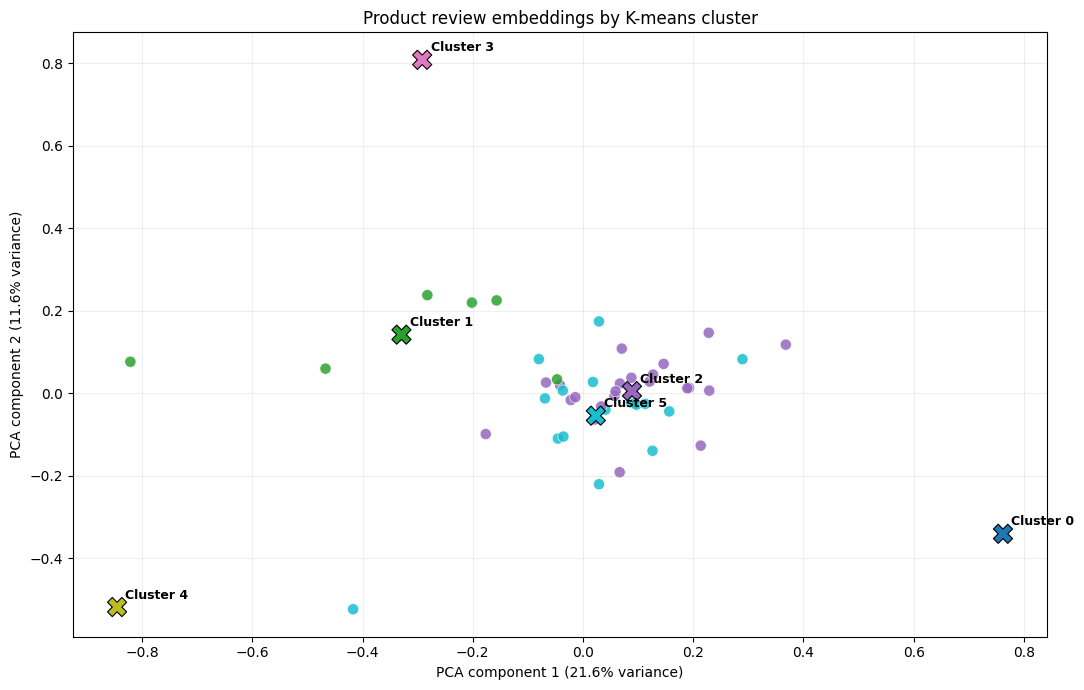

In [18]:
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display
import matplotlib.pyplot as plt

# Build one review-text document per product for cluster keyword analysis.
product_texts = (
    reviews.groupby("name")["text_for_embedding"]
    .apply(lambda texts: " ".join(texts.astype(str)))
    .reindex(product_vectors.index)
    .fillna("")
)
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000,
)
product_tfidf = vectorizer.fit_transform(product_texts)
terms = vectorizer.get_feature_names_out()

clustered_products = pd.DataFrame({
    "product": product_vectors.index,
    "cluster": pred,
    "review_count": reviews.groupby("name").size().reindex(product_vectors.index).to_numpy(),
})

cluster_report = []
for cluster_id in sorted(clustered_products["cluster"].unique()):
    mask = clustered_products["cluster"].to_numpy() == cluster_id
    cluster_positions = np.flatnonzero(mask)
    distances = np.linalg.norm(X[mask] - kmeans.cluster_centers_[cluster_id], axis=1)
    nearest_positions = cluster_positions[np.argsort(distances)[:3]]
    mean_tfidf = np.asarray(product_tfidf[mask].mean(axis=0)).ravel()
    top_terms = terms[np.argsort(mean_tfidf)[-10:][::-1]].tolist()
    representative_products = clustered_products.iloc[nearest_positions]["product"].tolist()

    review_examples = []
    for product in representative_products[:2]:
        product_reviews = reviews.loc[reviews["name"].eq(product), "reviews.text"].dropna()
        if not product_reviews.empty:
            snippet = re.sub(r"\s+", " ", str(product_reviews.iloc[0])).strip()
            review_examples.append(f"{product}: {snippet[:220]}")

    cluster_report.append({
        "cluster": cluster_id,
        "products": int(mask.sum()),
        "keywords": ", ".join(top_terms),
        "representative_products": representative_products,
        "review_examples": review_examples,
    })

cluster_report = pd.DataFrame(cluster_report)
display(cluster_report)

# Project the 100-dimensional product embeddings to two dimensions for inspection.
pca = PCA(n_components=2, random_state=100)
coordinates = pca.fit_transform(X)
centroid_coordinates = pca.transform(kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 7))
points = ax.scatter(
    coordinates[:, 0],
    coordinates[:, 1],
    c=pred,
    cmap="tab10",
    s=65,
    alpha=0.85,
    edgecolors="white",
    linewidths=0.5,
)
ax.scatter(
    centroid_coordinates[:, 0],
    centroid_coordinates[:, 1],
    marker="X",
    s=190,
    c=range(kmeans.n_clusters),
    cmap="tab10",
    edgecolors="black",
    linewidths=0.8,
)
for cluster_id, (center_x, center_y) in enumerate(centroid_coordinates):
    ax.annotate(
        f"Cluster {cluster_id}",
        (center_x, center_y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        weight="bold",
    )
ax.set_title("Product review embeddings by K-means cluster")
ax.set_xlabel(f"PCA component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PCA component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

,cluster,suggested_name,products,keywords,representative_products,review_examples
0,0,Fire TV Stick (single-product cluster),1,"absolutely loves, gift bought, absolutely, lov...",[Certified Refurbished Amazon Fire TV Stick (P...,[Certified Refurbished Amazon Fire TV Stick (P...
1,1,Kindle cases and covers,6,"cover, case, kindle, light, new, positive, pie...","[Amazon Kindle Lighted Leather Cover,,,\r\nKin...","[Amazon Kindle Lighted Leather Cover,,,\r\nKin..."
2,2,Fire tablets and Kindle readers,22,"great, tablet, kindle, love, easy, reading, re...","[Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include...","[Fire Tablet, 7 Display, Wi-Fi, 8 GB - Include..."
3,3,Kindle Voyage (single-product cluster),1,"ads, ok price, certain apps, willing, certain,...",[Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - B...,[Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - B...
4,4,Mixed accessory/device outlier,1,"cool, philips hue, philips, job great, amazon ...",[New Amazon Kindle Fire Hd 9w Powerfast Adapte...,[New Amazon Kindle Fire Hd 9w Powerfast Adapte...
5,5,Echo/Alexa speakers and smart home,17,"echo, great, alexa, music, home, love, use, pr...","[Echo (White),,,\r\nEcho (White),,,, Amazon - ...","[Echo (White),,,\r\nEcho (White),,,: Although ..."


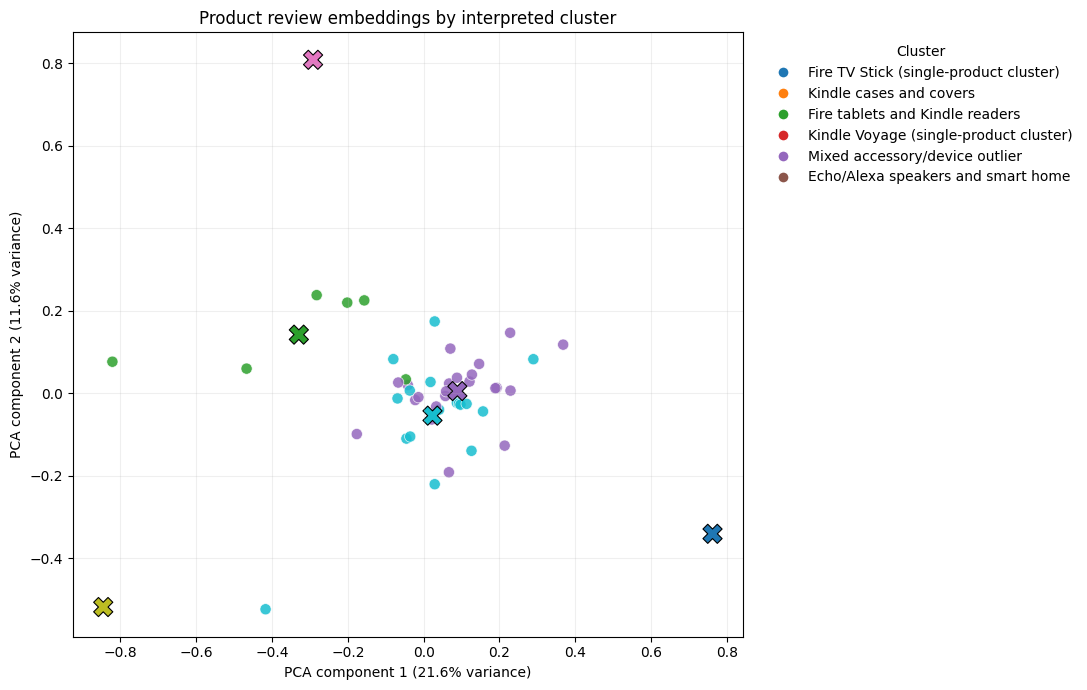

In [20]:
from matplotlib.lines import Line2D

cluster_names = {
    0: "Fire TV Stick (single-product cluster)",
    1: "Kindle cases and covers",
    2: "Fire tablets and Kindle readers",
    3: "Kindle Voyage (single-product cluster)",
    4: "Mixed accessory/device outlier",
    5: "Echo/Alexa speakers and smart home",
}

clustered_products["cluster_name"] = clustered_products["cluster"].map(cluster_names)
cluster_report["suggested_name"] = cluster_report["cluster"].map(cluster_names)

for annotation in list(ax.texts):
    annotation.remove()

legend_handles = [
    Line2D(
        [], [],
        marker="o",
        linestyle="None",
        markerfacecolor=plt.get_cmap("tab10")(cluster_id),
        markeredgecolor="white",
        markersize=8,
        label=cluster_names[cluster_id],
    )
    for cluster_id in sorted(cluster_names)
]
ax.legend(
    handles=legend_handles,
    title="Cluster",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False,
)
ax.set_title("Product review embeddings by interpreted cluster")
fig.subplots_adjust(right=0.68)
display(cluster_report[[
    "cluster", "suggested_name", "products", "keywords",
    "representative_products", "review_examples",
]])
display(fig)